In [50]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import svm

diabetes = load_diabetes()
x_diabetes = diabetes.data
y_diabetes = diabetes.target

display(x_diabetes)

print(f'Dimensão de X: {x_diabetes.shape}')
print(f'Dimensão de Y: {y_diabetes.shape}')

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

Dimensão de X: (442, 10)
Dimensão de Y: (442,)


In [ ]:
df_diabetes = pd.read_csv('/home/nes_pedro/FUND-IA/diabetes.csv')
display(df_diabetes)

y_diabetes_csv = df_diabetes['Outcome']

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,627.000,50,1
1,1,85,66,29,0,26.6,351.000,31,0
2,8,183,64,0,0,23.3,672.000,32,1
3,1,89,66,23,94,28.1,167.000,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,171.000,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,245.000,30,0
766,1,126,60,0,0,30.1,349.000,47,1


In [44]:
mediana_target = np.median(y_diabetes)

target_binario = np.where(y_diabetes > mediana_target, 1, 0)

print(f'Mediana: {mediana_target}')
print(f'Quantidade de classes 1: {len(target_binario[target_binario == 1])}')
print(f'Quantidade de classes 0: {len(target_binario[target_binario == 0])}')


Mediana: 140.5
Quantidade de classes 1: 221
Quantidade de classes 0: 221


In [45]:
train_x, test_x, train_y, test_y = train_test_split(x_diabetes, target_binario, random_state=123)

print(f'{len(test_x) / len(train_x):.4f}') # 25% / 75% = 1/3

0.3353


In [46]:
scaler = StandardScaler()

train_x_normalizado = scaler.fit_transform(train_x)
test_x_normalizado = scaler.transform(test_x)

print(train_x_normalizado)
print(test_x_normalizado)

[[-1.13117584 -0.96730167 -0.19582821 ... -0.06349972 -0.3797869
  -0.3034886 ]
 [-0.04410225 -0.96730167 -1.38826636 ... -0.06349972 -0.42508433
  -0.55420755]
 [ 0.49943454  1.03380366 -0.42081654 ... -0.81388915 -2.00822001
  -0.38706158]
 ...
 [ 0.49943454  1.03380366  1.28909477 ...  3.14816705  2.77037449
   1.61869003]
 [ 1.04297133 -0.96730167  1.26659594 ... -0.06349972  2.16198642
   0.69938721]
 [ 0.73237888 -0.96730167 -0.8032967  ... -0.06349972  0.64537542
   1.95298196]]
[[ 0.11119397  1.03380366 -0.03833638 ... -0.06349972  0.79510333
  -0.3034886 ]
 [-0.19939848  1.03380366 -0.37581888 ...  1.43727914  0.00249308
   0.36509527]
 [ 0.96532322 -0.96730167  0.81661928 ... -0.26610487  1.33431331
   1.11725213]
 ...
 [ 0.88767511  1.03380366  0.41164028 ... -0.06349972  0.64537542
   0.11437632]
 [ 1.58650813 -0.96730167  1.7840691  ... -0.06349972  0.12587645
   1.70226301]
 [ 1.04297133 -0.96730167 -0.89329204 ... -0.06349972 -0.54278183
  -1.30636441]]


In [47]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2,
            weights='distance')

knn.fit(train_x_normalizado, train_y)
previsao_knn = knn.predict(test_x_normalizado)

Previsão do modelo: [0 0 1 1 0 0 1 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 1 0 0
 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 1 1 1 1 1 1 1 0 0 0 1 1 1 0 0 1 0 0 0 0 1 1
 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 1 0 1 1 0 0 0 0 1 0 0 0 1 1 1 0] 

Gabarito: [1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0
 0 1 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1
 0 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 0 0 0 1 0 1 1 0 0 1 0 0 1 0 1 0 0 1 1 1 0] 

Acurácia: 68.4685%
Média de Acurácia: 67.4343%
Desvio Padrão: 4.6563%
[[41 16]
 [19 35]]


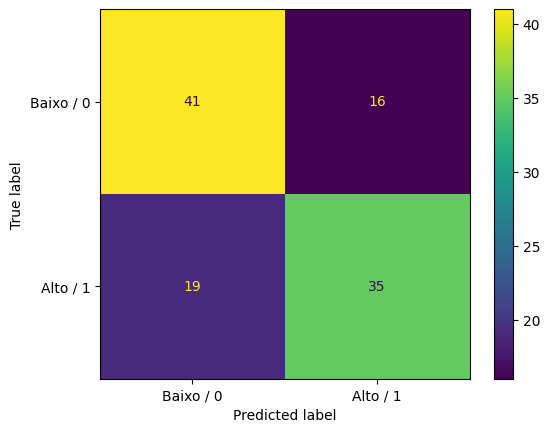

In [48]:
accuracy = np.mean(previsao_knn == test_y)
print(f'Previsão do modelo: {previsao_knn}', '\n')
print(f'Gabarito: {test_y}', '\n')
print(f'Acurácia: {accuracy:.4%}')

scores = cross_val_score(knn, x_diabetes, target_binario, cv=10)

print(f'Média de Acurácia: {np.mean(scores):.4%}')
print(f'Desvio Padrão: {np.std(scores):.4%}')

matriz_confusao = confusion_matrix(test_y, previsao_knn)
print(matriz_confusao)
plot_matriz = ConfusionMatrixDisplay(matriz_confusao, display_labels=['Baixo / 0', 'Alto / 1'])
plot_matriz.plot()

Previsão do modelo: [1 0 1 1 1 0 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 0 1 1 1 1 0 0
 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 0 1 1 1 0] 

Gabarito: [1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0
 0 1 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1
 0 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 0 0 0 1 0 1 1 0 0 1 0 0 1 0 1 0 0 1 1 1 0] 

Acurácia: 74.7748%
Média de Acurácia: 74.1931%
Desvio Padrão: 6.4735%
[[43 14]
 [14 40]]


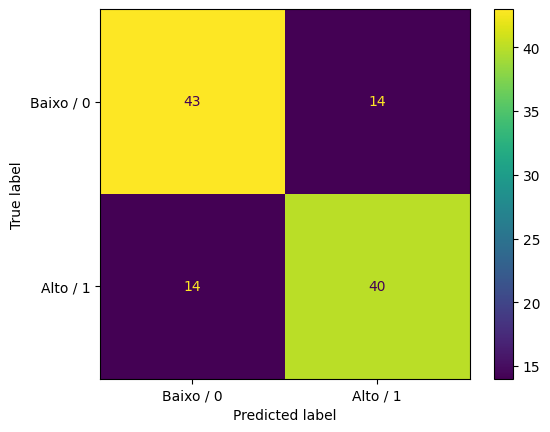

In [52]:
svm_modelo = svm.SVC(kernel='linear', C=1.0)
svm_modelo.fit(train_x_normalizado, train_y)
previsoes_svm_modelo = svm_modelo.predict(test_x_normalizado)

accuracy_svm_modelo = np.mean(previsoes_svm_modelo == test_y)
print(f'Previsão do modelo: {previsoes_svm_modelo}', '\n')
print(f'Gabarito: {test_y}', '\n')
print(f'Acurácia: {accuracy_svm_modelo:.4%}')

cross = cross_val_score(svm_modelo, x_diabetes, target_binario)

print(f'Média de Acurácia: {np.mean(cross):.4%}')
print(f'Desvio Padrão: {np.std(cross):.4%}')

matriz_confusao = confusion_matrix(test_y, previsoes_svm_modelo)
print(matriz_confusao)
plot_matriz = ConfusionMatrixDisplay(matriz_confusao, display_labels=['Baixo / 0', 'Alto / 1'])
plot_matriz.plot()

In [ ]:
"""O svm teve melhores resultados, tendo mais acertos e uma média de acurácia maior, 
perdendo apenas no desvio padrão das validações cruzadas."""

'\nO svm teve melhores resultados, tendo mais acertos e uma média de acurácia maior, \nperdendo apenas no desvio padrão das validações cruzadas.'

In [61]:
print(diabetes.feature_names)
novo_teste = np.array([[0.05, 0.05, 0.03, 0.02, -0.01, -0.02, 0.01, 0.03, 0.04, 0.02]])
novo_teste_normalizado = scaler.transform(novo_teste)

predict_svm = svm_modelo.predict(novo_teste_normalizado)
predict_knn = knn.predict(novo_teste_normalizado)

print(f'Previsão SVM : {predict_svm}')
print(f'Previsão KNN : {predict_knn}')

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Previsão SVM : [1]
Previsão KNN : [1]
